In [3]:
from google.colab import files
uploaded = files.upload()

Saving f1_results.xlsx to f1_results.xlsx


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
df = pd.read_excel("f1_results.xlsx")

In [5]:
df.head(5) #first 5 rows

,season,round,race_name,driver_id,driver_name,constructor_id,constructor,grid,position,points,laps,status,time,fastest_lap,fastest_lap_rank
0,1950,1,British Grand Prix,farina,Nino Farina,alfa,Alfa Romeo,1,1,9.0,70,Finished,02:13:23.600000,NaN,NaN
1,1950,1,British Grand Prix,fagioli,Luigi Fagioli,alfa,Alfa Romeo,2,2,6.0,70,Finished,2.6,NaN,NaN
2,1950,1,British Grand Prix,reg_parnell,Reg Parnell,alfa,Alfa Romeo,4,3,4.0,70,Finished,52,NaN,NaN
3,1950,1,British Grand Prix,cabantous,Yves Cabantous,lago,Talbot-Lago,6,4,3.0,68,+2 Laps,NaN,NaN,NaN
4,1950,1,British Grand Prix,rosier,Louis Rosier,lago,Talbot-Lago,9,5,2.0,68,+2 Laps,NaN,NaN,NaN


In [6]:
df.tail(5) #last 5 rows

,season,round,race_name,driver_id,driver_name,constructor_id,constructor,grid,position,points,laps,status,time,fastest_lap,fastest_lap_rank
25934,2026,3,Japanese Grand Prix,alonso,Fernando Alonso,aston_martin,Aston Martin,21,18,0.0,52,Lapped,26.548,00:01:36.221000,20.0
25935,2026,3,Japanese Grand Prix,bottas,Valtteri Bottas,cadillac,Cadillac F1 Team,20,19,0.0,52,Lapped,42.621,00:01:36.269000,21.0
25936,2026,3,Japanese Grand Prix,albon,Alexander Albon,williams,Williams,17,20,0.0,51,Lapped,5.067,00:01:33.427000,7.0
25937,2026,3,Japanese Grand Prix,stroll,Lance Stroll,aston_martin,Aston Martin,22,21,0.0,30,Retired,NaN,00:01:37.217000,22.0
25938,2026,3,Japanese Grand Prix,bearman,Oliver Bearman,haas,Haas F1 Team,18,22,0.0,20,Retired,NaN,00:01:35.604000,18.0


In [7]:
df.shape #shows rows-column

(25939, 15)

In [8]:
df.info()  #dataset info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25939 entries, 0 to 25938
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   season            25939 non-null  int64  
 1   round             25939 non-null  int64  
 2   race_name         25939 non-null  object 
 3   driver_id         25939 non-null  object 
 4   driver_name       25939 non-null  object 
 5   constructor_id    25939 non-null  object 
 6   constructor       25939 non-null  object 
 7   grid              25939 non-null  int64  
 8   position          25939 non-null  int64  
 9   points            25939 non-null  float64
 10  laps              25939 non-null  int64  
 11  status            25939 non-null  object 
 12  time              8354 non-null   object 
 13  fastest_lap       8785 non-null   object 
 14  fastest_lap_rank  8785 non-null   float64
dtypes: float64(2), int64(5), object(8)
memory usage: 3.0+ MB


In [9]:
df.columns #column names

Index(['season', 'round', 'race_name', 'driver_id', 'driver_name',
       'constructor_id', 'constructor', 'grid', 'position', 'points', 'laps',
       'status', 'time', 'fastest_lap', 'fastest_lap_rank'],
      dtype='object')

In [10]:
df.describe() #summary

,season,round,grid,position,points,laps,fastest_lap_rank
count,25939.000000,25939.000000,25939.000000,25939.000000,25939.000000,25939.000000,8785.000000
mean,1992.570222,8.605228,11.710783,11.935618,2.155614,48.900883,10.621172
std,20.599544,5.175543,6.878780,6.877435,4.534585,28.025333,5.932522
min,1950.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,1977.000000,4.000000,6.000000,6.000000,0.000000,30.000000,6.000000
50%,1993.000000,8.000000,11.000000,12.000000,0.000000,53.000000,11.000000
75%,2011.000000,13.000000,17.000000,17.000000,2.000000,67.000000,16.000000
max,2026.000000,24.000000,34.000000,39.000000,50.000000,200.000000,24.000000


In [11]:
#Data Cleaning

df.isnull().sum() #missing values
(df.isnull().sum()/len(df))*100 #percentage of null

,0
season,0.000000
round,0.000000
race_name,0.000000
driver_id,0.000000
driver_name,0.000000
constructor_id,0.000000
constructor,0.000000
grid,0.000000
position,0.000000
points,0.000000


In [13]:
df.duplicated().sum() #check duplicates

np.int64(0)

In [14]:
df.drop_duplicates(inplace=True) #remove duplicates

In [15]:
#handle missingvalues
df.fillna(method='ffill', inplace=True) #fill

/tmp/ipykernel_763/582613163.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True) #fill


In [16]:
df.dtypes #check data types

,0
season,int64
round,int64
race_name,object
driver_id,object
driver_name,object
constructor_id,object
constructor,object
grid,int64
position,int64
points,float64


In [18]:
#FEATURE

df['is_win'] = np.where(df['position'] == 1, 1, 0)

In [19]:
df['podium'] = np.where(df['position'] <= 3, 1, 0)
df['positions_gained'] = df['grid'] - df['position']
df['finished_race'] = np.where(df['status'] == 'Finished', 1, 0)
df['high_points'] = np.where(df['points'] >= 15, "High", "Low")

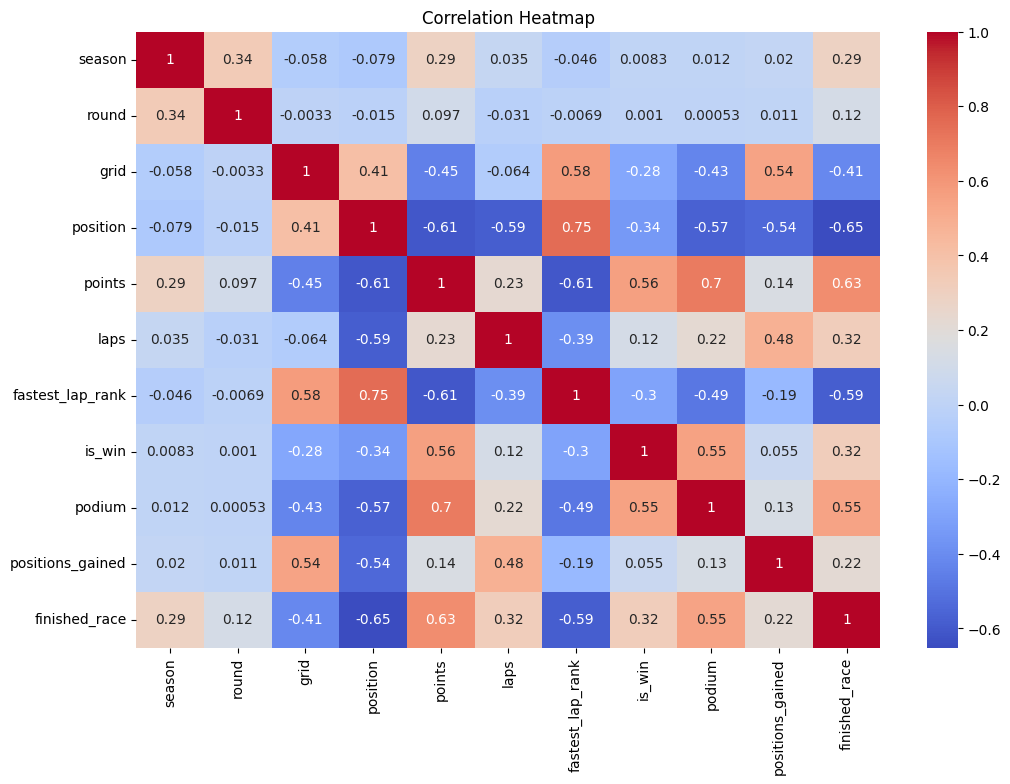

In [20]:
#EDA

#1. heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

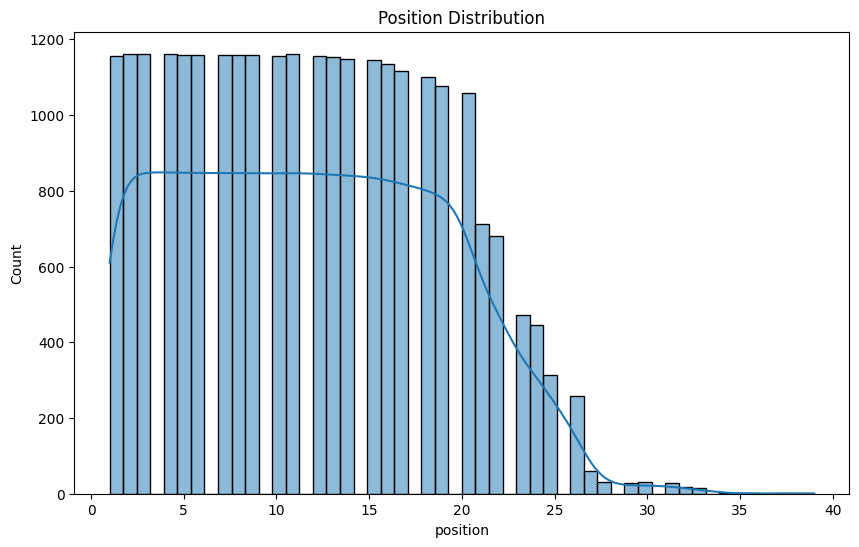

In [93]:
#2 histogram
plt.figure(figsize=(10,6))

sns.histplot(df['position'], kde=True)

plt.title("Position Distribution")

plt.show()

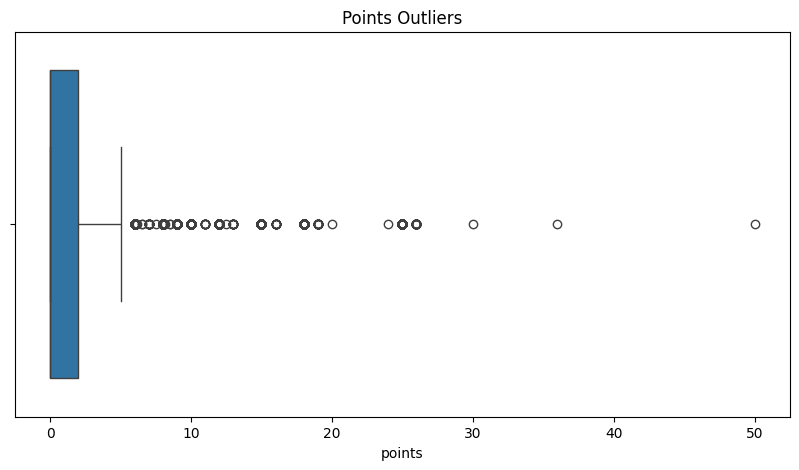

In [92]:
#3 boxplot
plt.figure(figsize=(10,5))

sns.boxplot(x=df['points'])

plt.title("Points Outliers")

plt.show()

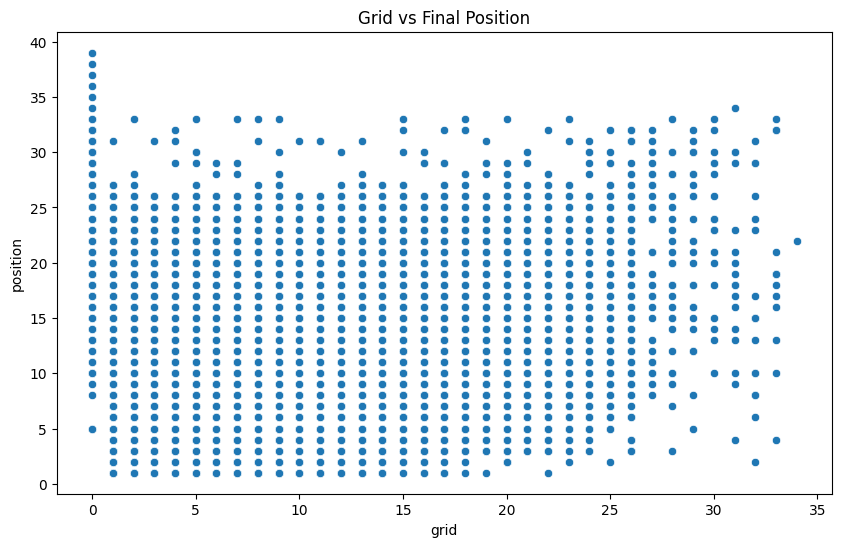

In [23]:
#4 scatter plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='grid',
    y='position',
    data=df
)

plt.title("Grid vs Final Position")

plt.show()

/tmp/ipykernel_763/3159785785.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


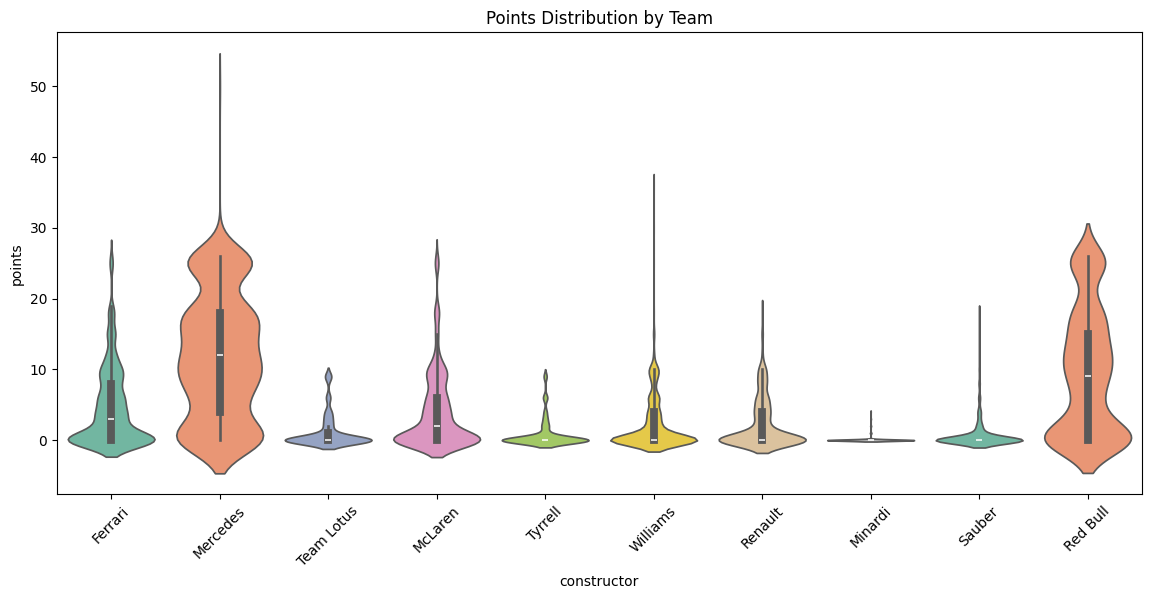

In [27]:
#5. violin plot
top_const = df['constructor'].value_counts().head(10).index

filtered_df = df[df['constructor'].isin(top_const)]

plt.figure(figsize=(14,6))

sns.violinplot(
    x='constructor',
    y='points',
    data=filtered_df,
    palette='Set2'
)

plt.xticks(rotation=45)

plt.title("Points Distribution by Team")

plt.show()

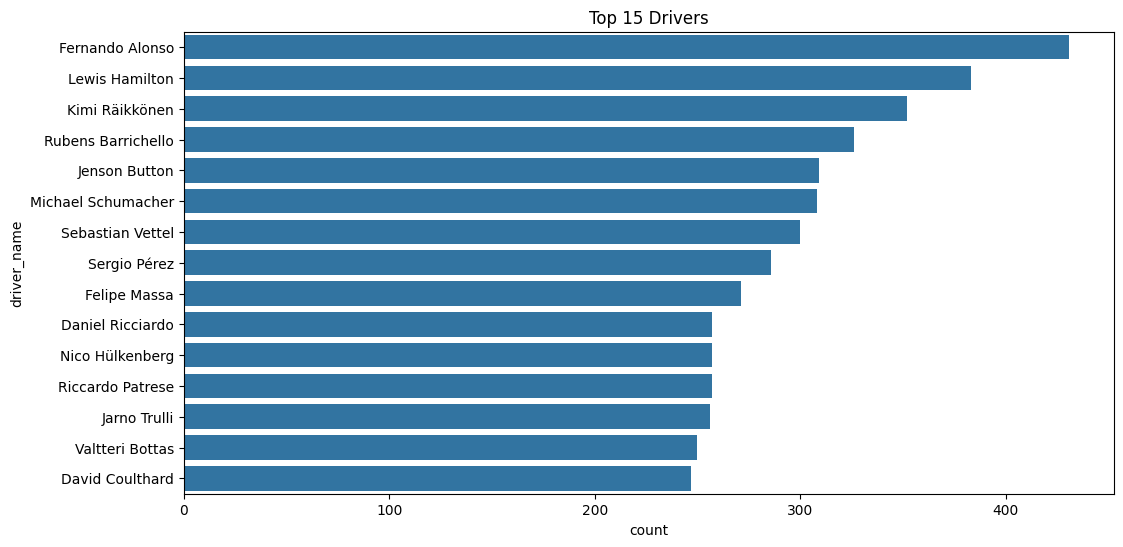

In [31]:
#6 count plot
plt.figure(figsize=(12,6))

sns.countplot(
    y=df['driver_name'],
    order=df['driver_name'].value_counts().iloc[:15].index
)

plt.title("Top 15 Drivers")

plt.show()

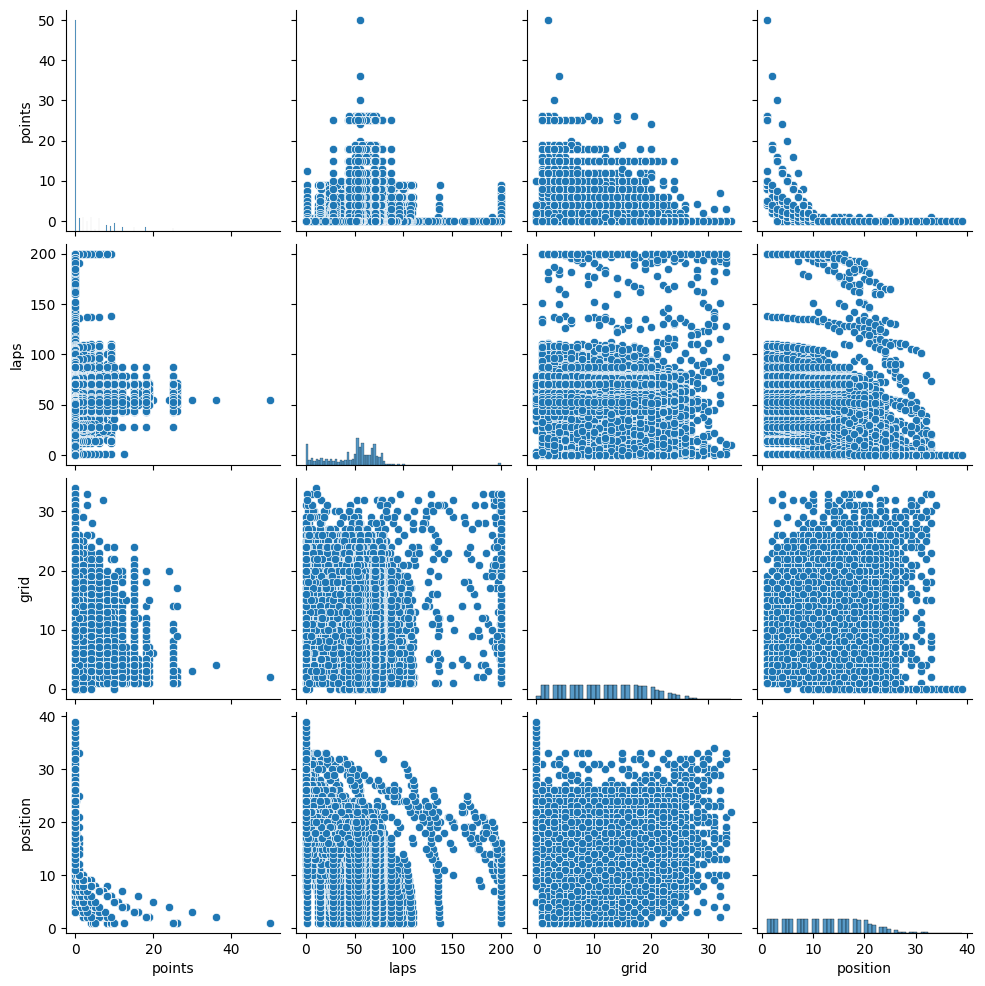

In [32]:
#7. pairplot
sns.pairplot(
    df[['points','laps','grid','position']]
)

plt.show()

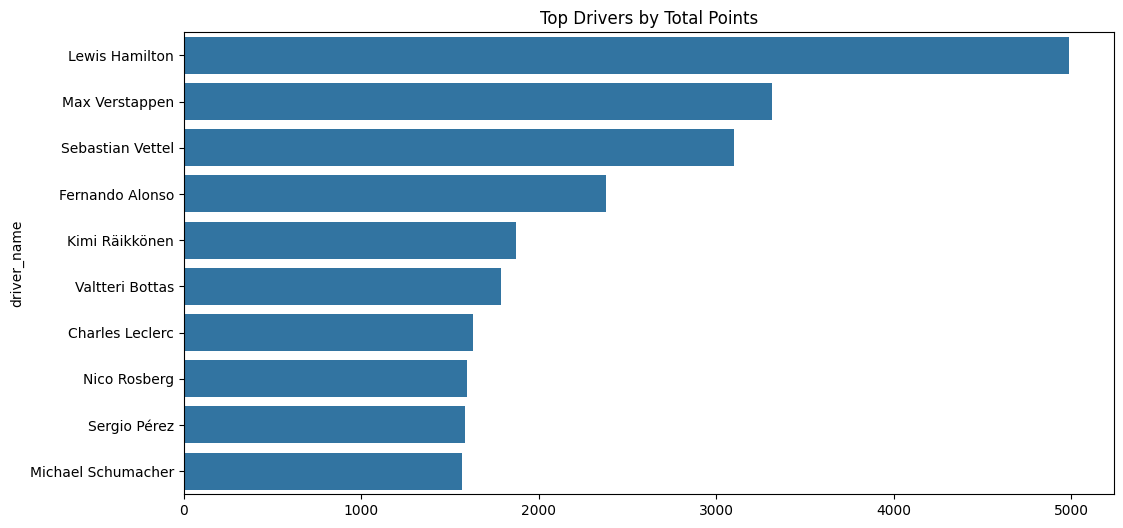

In [40]:
#8. barplot
top_drivers = (
    df.groupby('driver_name')['points']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_drivers.values,
    y=top_drivers.index
)

plt.title("Top Drivers by Total Points")

plt.show()

In [86]:
#9. a. Interactive Plotly Graph
fig = px.scatter(
    df,
    x='grid',
    y='position',
    color='constructor',
    hover_data=['driver_name'],
    title='Grid Position vs Final Position'
)

fig.show()

In [34]:
#b. Treemap
fig = px.treemap(
    df,
    path=['constructor'],
    values='points',
    title='Constructor Points Distribution'
)

fig.show()

In [35]:
#c. Piechart
fig = px.sunburst(
    df,
    path=['constructor', 'driver_name'],
    values='points'
)

fig.show()

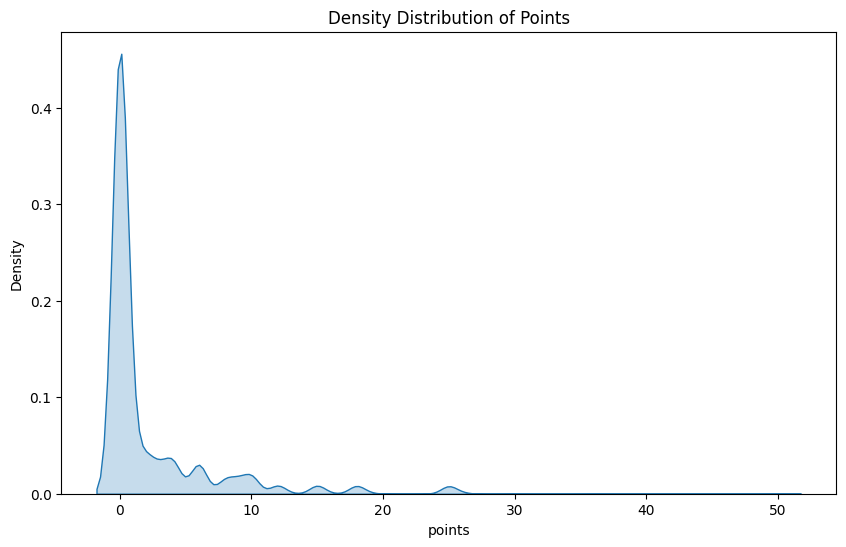

In [36]:
#KDE
plt.figure(figsize=(10,6))

sns.kdeplot(df['points'], fill=True)

plt.title("Density Distribution of Points")
plt.show()



1.   Which drivers scored the most total points?
2.   Which drivers have the most wins?
3. Which drivers achieved most podium finishes?
4. Which drivers gained the most positions during races?
5. Which drivers are most consistent?
6. Which constructors scored the highest points?
7. Which constructor dominated each season?
8. Which constructors had best average finishing position?
9. Which constructors had most wins?
10. Which constructors improved over time?
11. Which races had the highest average points?
12. Which races had most DNFs?
13. Which races were most competitive?
14. Which races had the highest average laps completed?
15. Does grid position affect final position?
16. Which drivers had best fastest lap rankings?
17. Is fastest lap related to race wins?
18. Which constructors dominate fastest laps?
19. Which seasons had highest average points?
20. How has driver performance changed across seasons?



In [41]:
#1
top_drivers = (
    df.groupby('driver_name')['points']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_drivers

,points
driver_name,
Lewis Hamilton,4990.5
Max Verstappen,3313.5
Sebastian Vettel,3098.0
Fernando Alonso,2380.0
Kimi Räikkönen,1873.0
Valtteri Bottas,1788.0
Charles Leclerc,1630.0
Nico Rosberg,1594.5
Sergio Pérez,1585.0


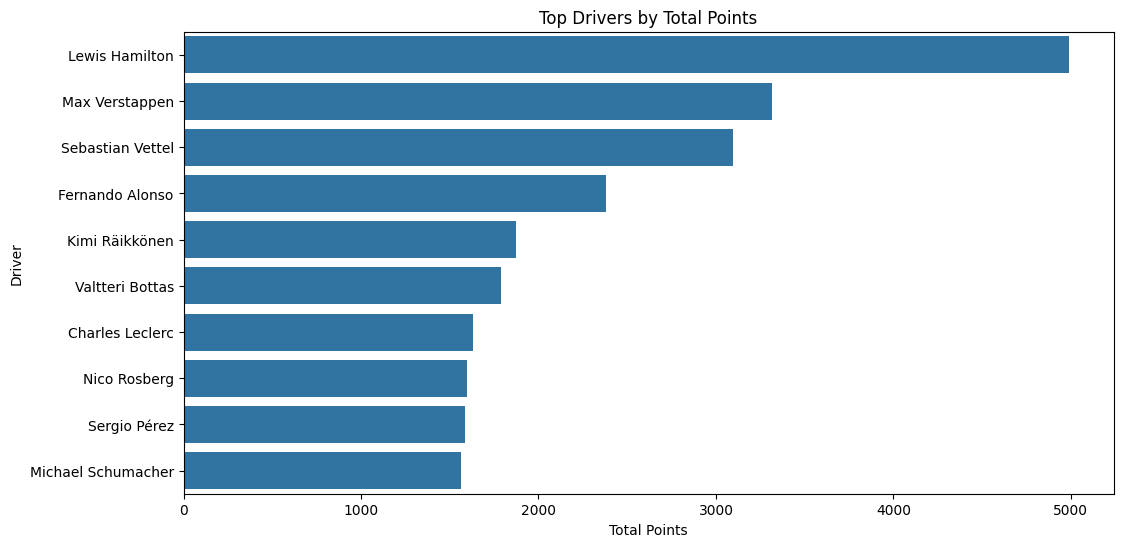

In [42]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_drivers.values,
    y=top_drivers.index
)

plt.title("Top Drivers by Total Points")
plt.xlabel("Total Points")
plt.ylabel("Driver")

plt.show()

In [43]:
#2 driver with most wins
wins = (
    df[df['position'] == 1]
    ['driver_name']
    .value_counts()
    .head(10)
)

wins

,count
driver_name,
Lewis Hamilton,105
Michael Schumacher,91
Max Verstappen,71
Sebastian Vettel,53
Alain Prost,51
Ayrton Senna,41
Fernando Alonso,32
Nigel Mansell,31
Jackie Stewart,27


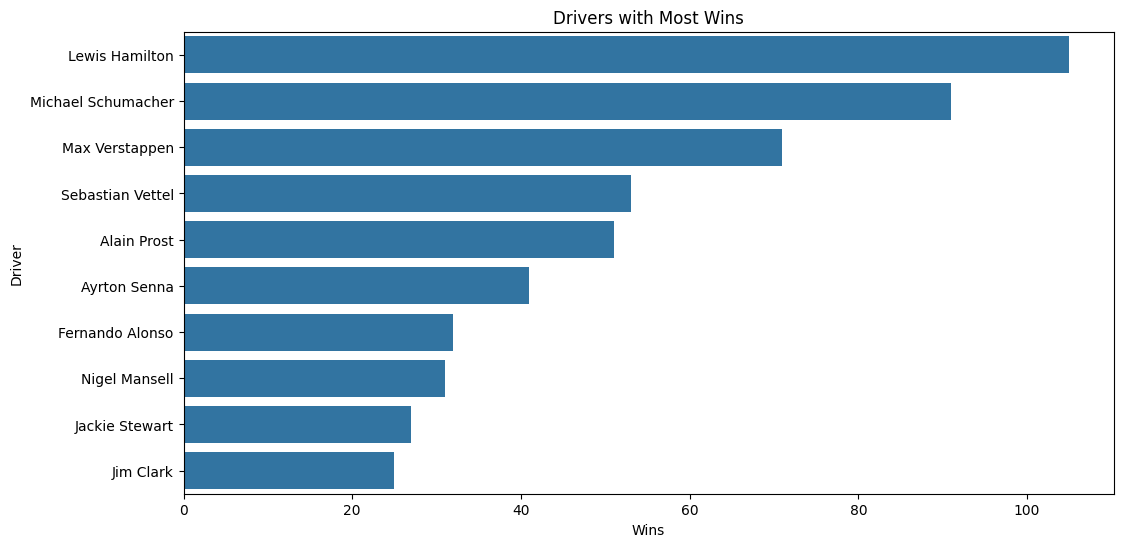

In [44]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=wins.values,
    y=wins.index
)

plt.title("Drivers with Most Wins")
plt.xlabel("Wins")
plt.ylabel("Driver")

plt.show()

In [45]:
#3
podiums = (
    df[df['position'] <= 3]
    ['driver_name']
    .value_counts()
    .head(10)
)

podiums

,count
driver_name,
Lewis Hamilton,203
Michael Schumacher,155
Max Verstappen,127
Sebastian Vettel,122
Alain Prost,106
Fernando Alonso,106
Kimi Räikkönen,103
Ayrton Senna,80
Rubens Barrichello,68


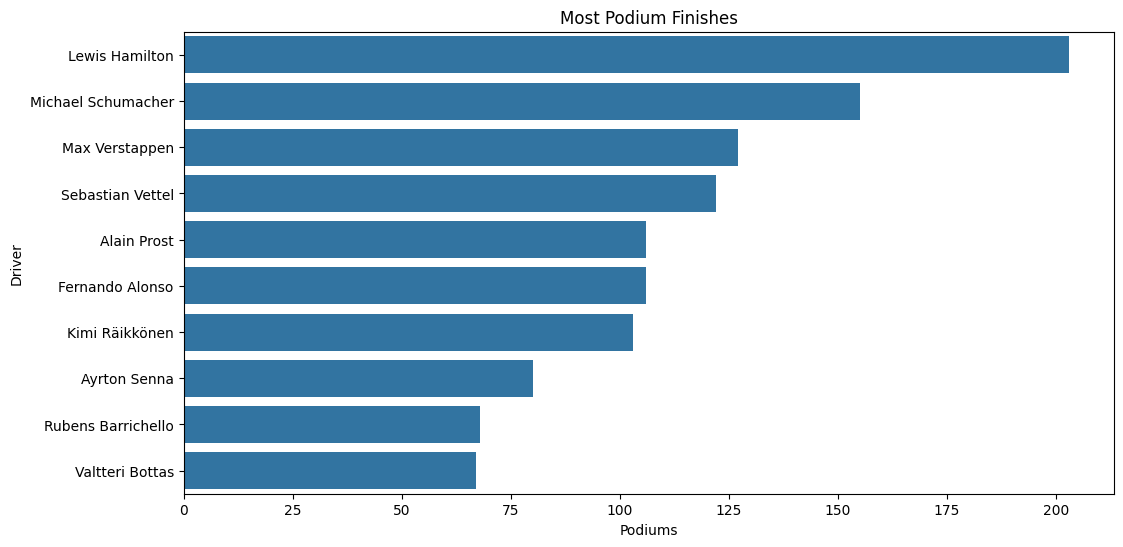

In [46]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=podiums.values,
    y=podiums.index
)

plt.title("Most Podium Finishes")
plt.xlabel("Podiums")
plt.ylabel("Driver")

plt.show()

In [47]:
#4
df['positions_gained'] = df['grid'] - df['position']

gained = (
    df.groupby('driver_name')['positions_gained']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

gained


,positions_gained
driver_name,
George Amick,23.0
Bud Tingelstad,19.0
Carl Forberg,17.0
Ernst Klodwig,17.0
Mike Sparken,16.0
Larry Crockett,16.0
Dieter Quester,16.0
Bill Mackey,14.0
Frank Armi,14.0


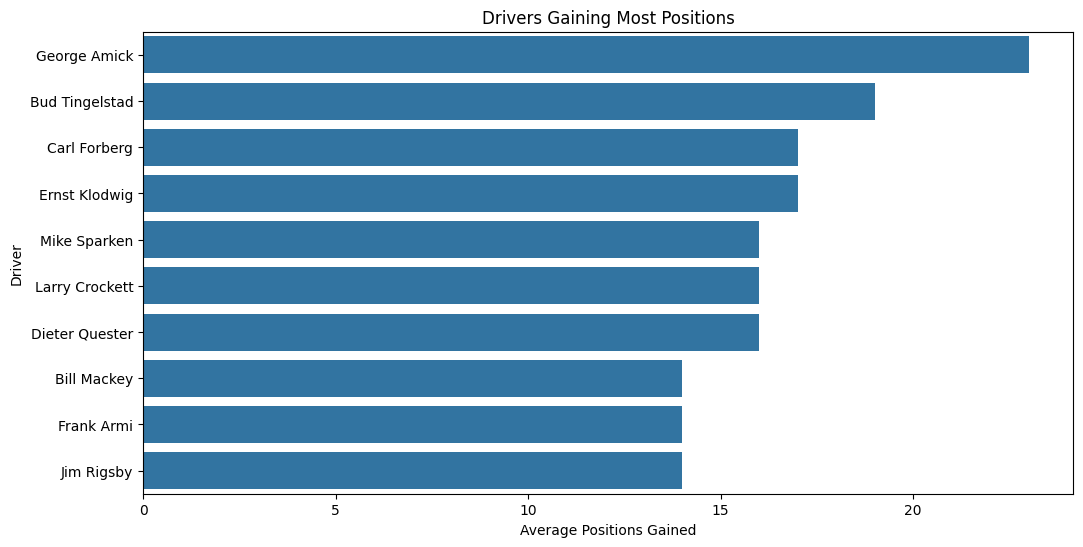

In [48]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=gained.values,
    y=gained.index
)

plt.title("Drivers Gaining Most Positions")
plt.xlabel("Average Positions Gained")
plt.ylabel("Driver")

plt.show()

In [49]:
#5
consistent = (
    df.groupby('driver_name')['position']
    .mean()
    .sort_values()
    .head(10)
)

consistent

,position
driver_name,
George Amick,2.000000
Dorino Serafini,2.000000
Lee Wallard,3.500000
Luigi Fagioli,4.375000
Juan Fangio,4.793103
Oscar Gálvez,5.000000
Eric Thompson,5.000000
Joie Chitwood,5.000000
Lewis Hamilton,5.232376


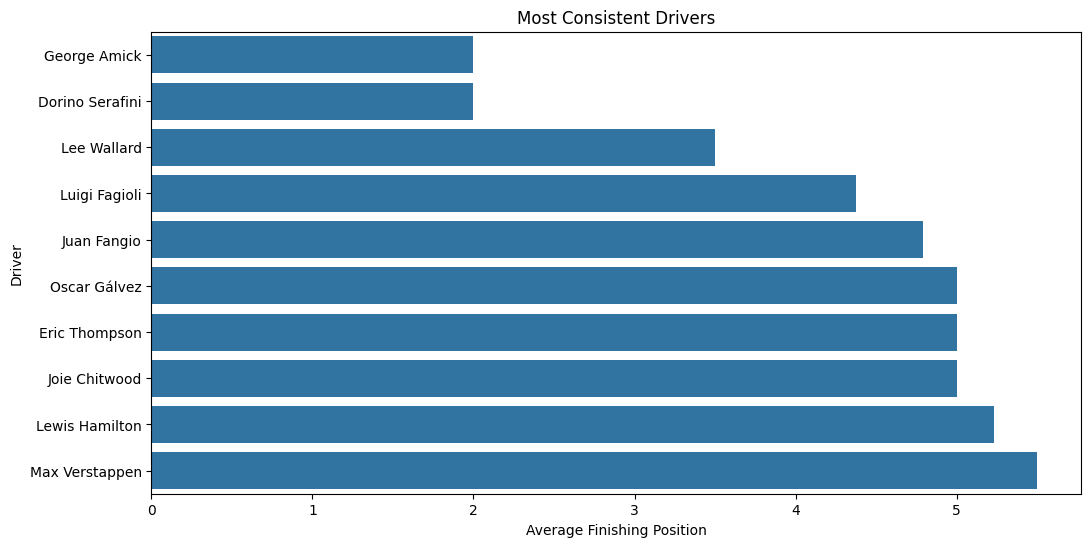

In [50]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=consistent.values,
    y=consistent.index
)

plt.title("Most Consistent Drivers")
plt.xlabel("Average Finishing Position")
plt.ylabel("Driver")

plt.show()

In [51]:
#6
constructors = (
    df.groupby('constructor')['points']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

constructors

,points
constructor,
Ferrari,11528.27
Mercedes,8277.64
Red Bull,8099.00
McLaren,7835.50
Williams,3767.00
Renault,1777.00
Force India,1098.00
Team Lotus,995.00
Benetton,861.50


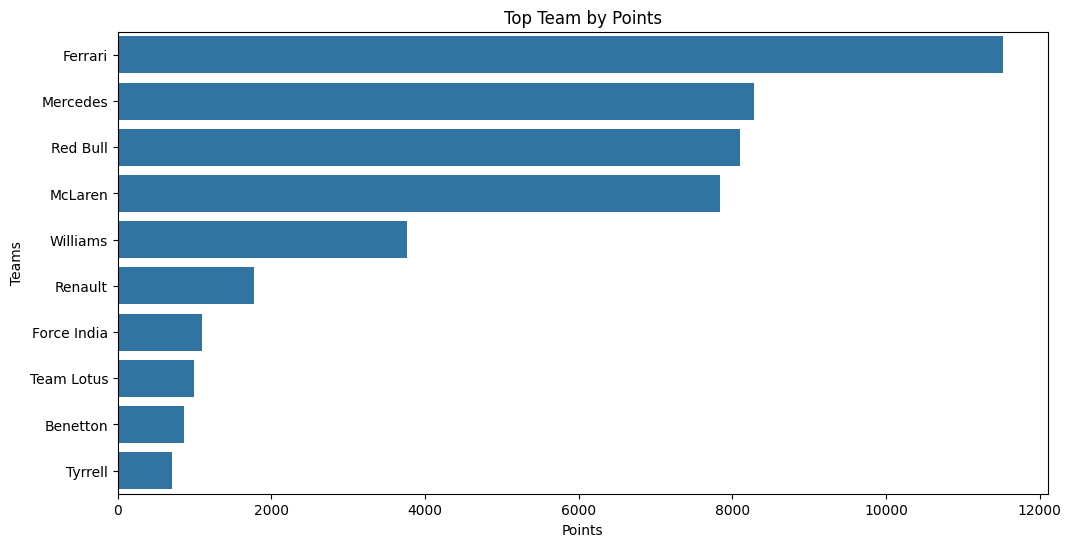

In [56]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=constructors.values,
    y=constructors.index
)

plt.title("Top Team by Points")
plt.xlabel("Points")
plt.ylabel("Teams")

plt.show()

In [53]:
#7
season_domination = (
    df.groupby(['season','constructor'])['points']
    .sum()
    .reset_index()
)

top_each_season = (
    season_domination.sort_values(
        ['season','points'],
        ascending=[True,False]
    )
    .drop_duplicates('season')
)

top_each_season.head()

,season,constructor,points
1,1950,Alfa Romeo,89.00
30,1951,Ferrari,86.00
57,1952,Ferrari,120.50
79,1953,Ferrari,122.50
96,1954,Ferrari,80.28


In [110]:
#Animated
fig = px.bar(
    season_points,
    x='constructor',
    y='points',
    color='constructor',
    animation_frame='season',
    title='Constructor Dominance Animation'
)

fig.show()

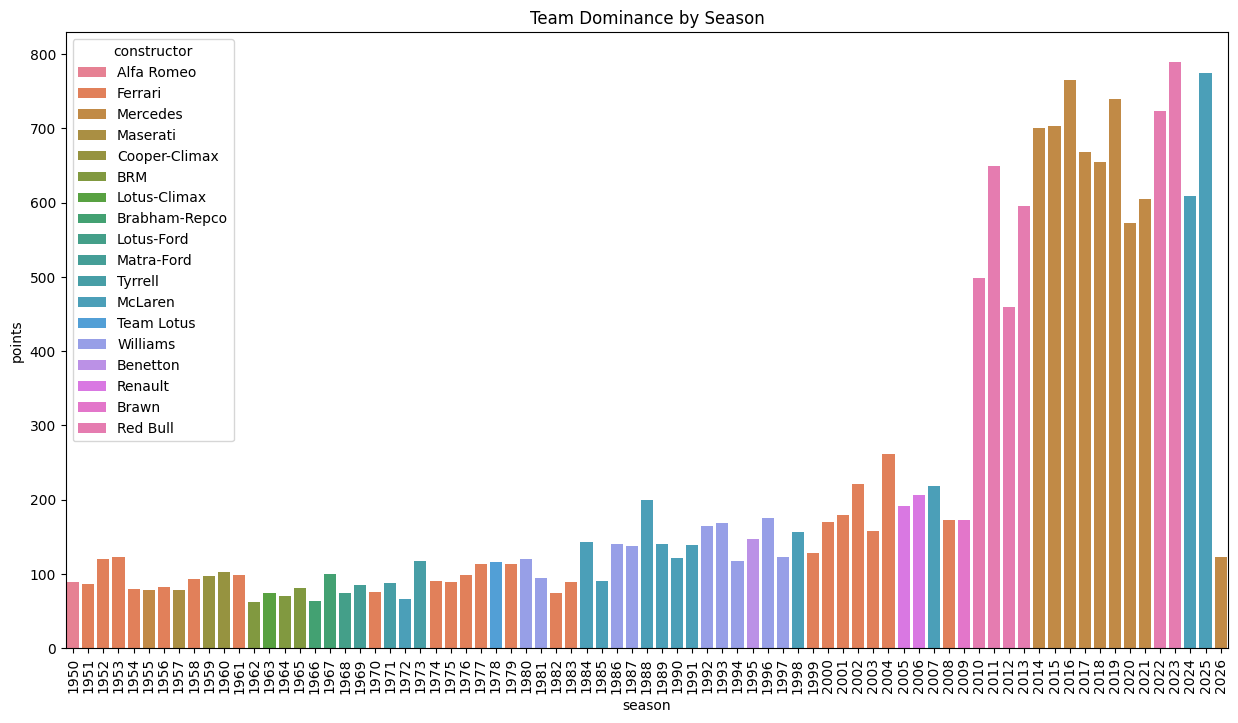

In [57]:
plt.figure(figsize=(15,8))

sns.barplot(
    x='season',
    y='points',
    hue='constructor',
    data=top_each_season
)

plt.xticks(rotation=90)

plt.title("Team Dominance by Season")

plt.show()

In [58]:
#8
avg_finish = (
    df.groupby('constructor')['position']
    .mean()
    .sort_values()
    .head(10)
)

avg_finish

,position
constructor,
Brawn,4.882353
Matra-Ford,5.650000
Mercedes,5.995745
Red Bull,7.421615
BRM-Ford,8.000000
Moore,8.000000
Ferrari,8.204344
Brabham-Repco,8.626667
McLaren-Ford,8.755814


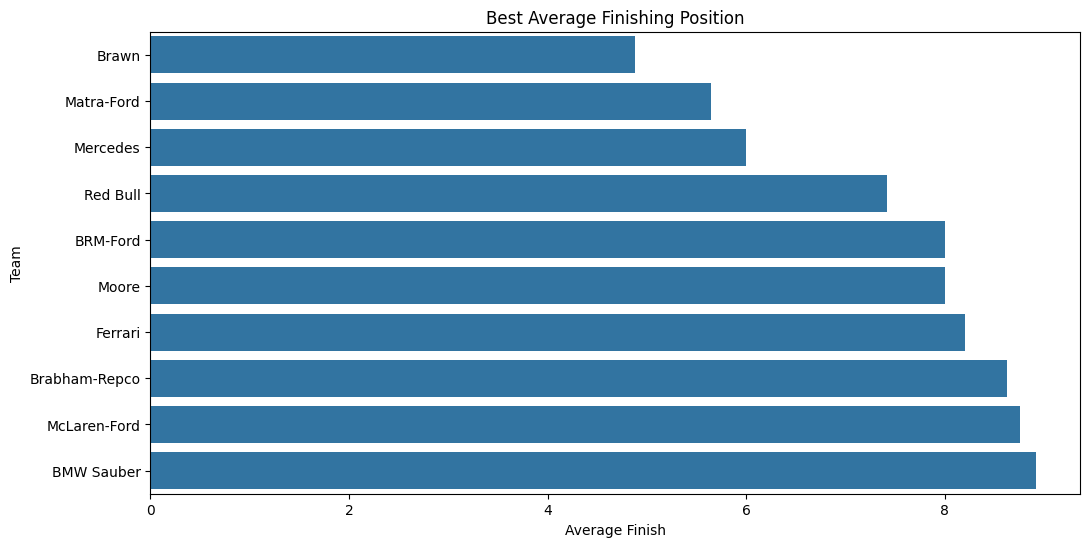

In [60]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_finish.values,
    y=avg_finish.index
)

plt.title("Best Average Finishing Position")
plt.xlabel("Average Finish")
plt.ylabel("Team")

plt.show()

In [61]:
#9
constructor_wins = (
    df[df['position']==1]
    ['constructor']
    .value_counts()
    .head(10)
)

constructor_wins

,count
constructor,
Ferrari,249
McLaren,199
Mercedes,134
Red Bull,130
Williams,114
Team Lotus,45
Renault,35
Benetton,27
Brabham,23


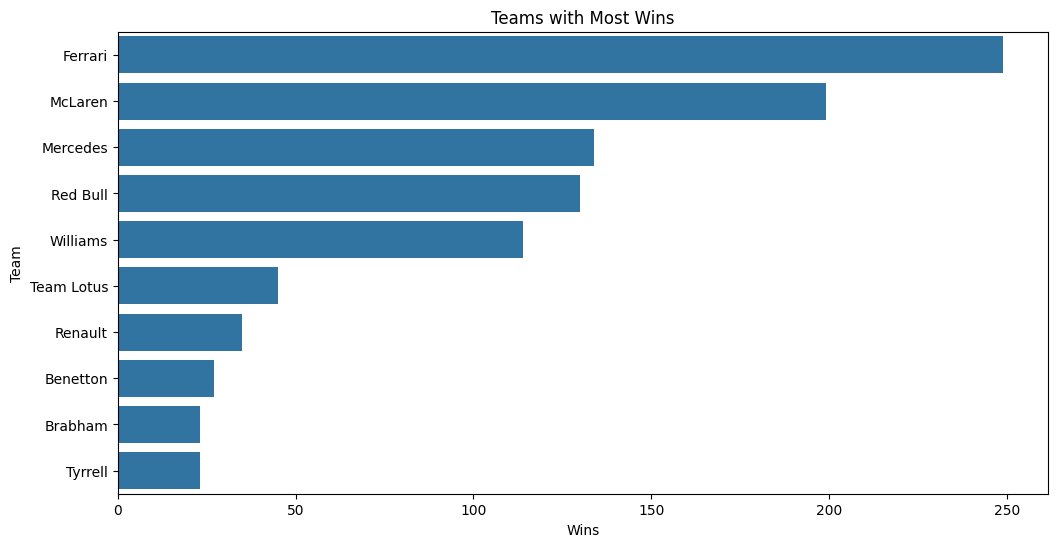

In [63]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=constructor_wins.values,
    y=constructor_wins.index
)

plt.title("Teams with Most Wins")
plt.xlabel("Wins")
plt.ylabel("Team")

plt.show()

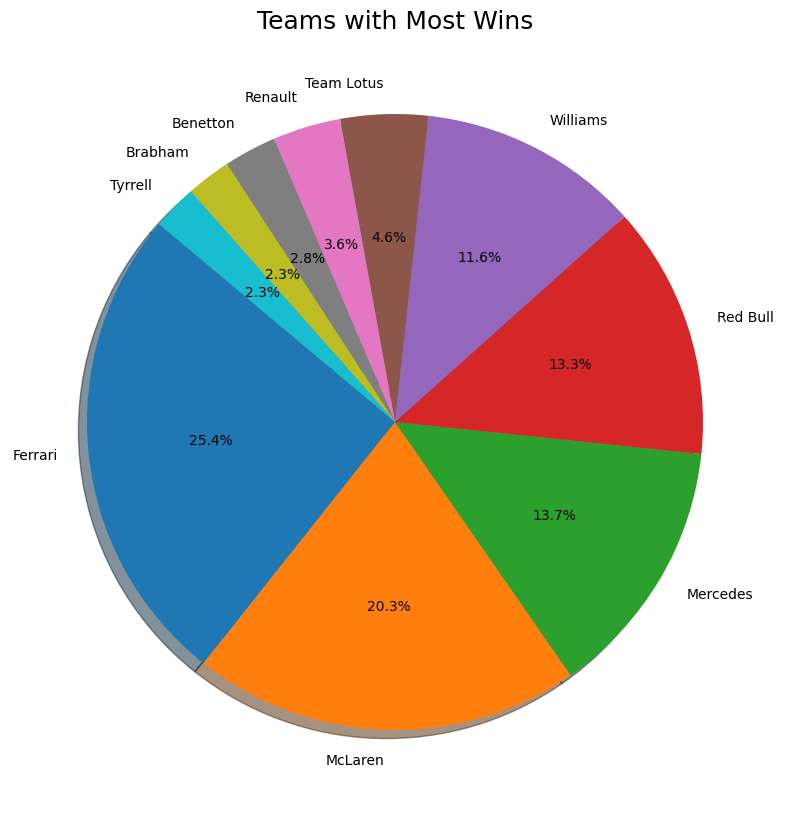

In [107]:
plt.figure(figsize=(10,10))

plt.pie(
    constructor_wins.values,
    labels=constructor_wins.index,
    autopct='%1.1f%%',
    shadow=True,
    startangle=140
)

plt.title(
    "Teams with Most Wins",
    fontsize=18
)

plt.show()

In [64]:
#10
constructor_trend = (
    df.groupby(['season','constructor'])['points']
    .sum()
    .reset_index()
)

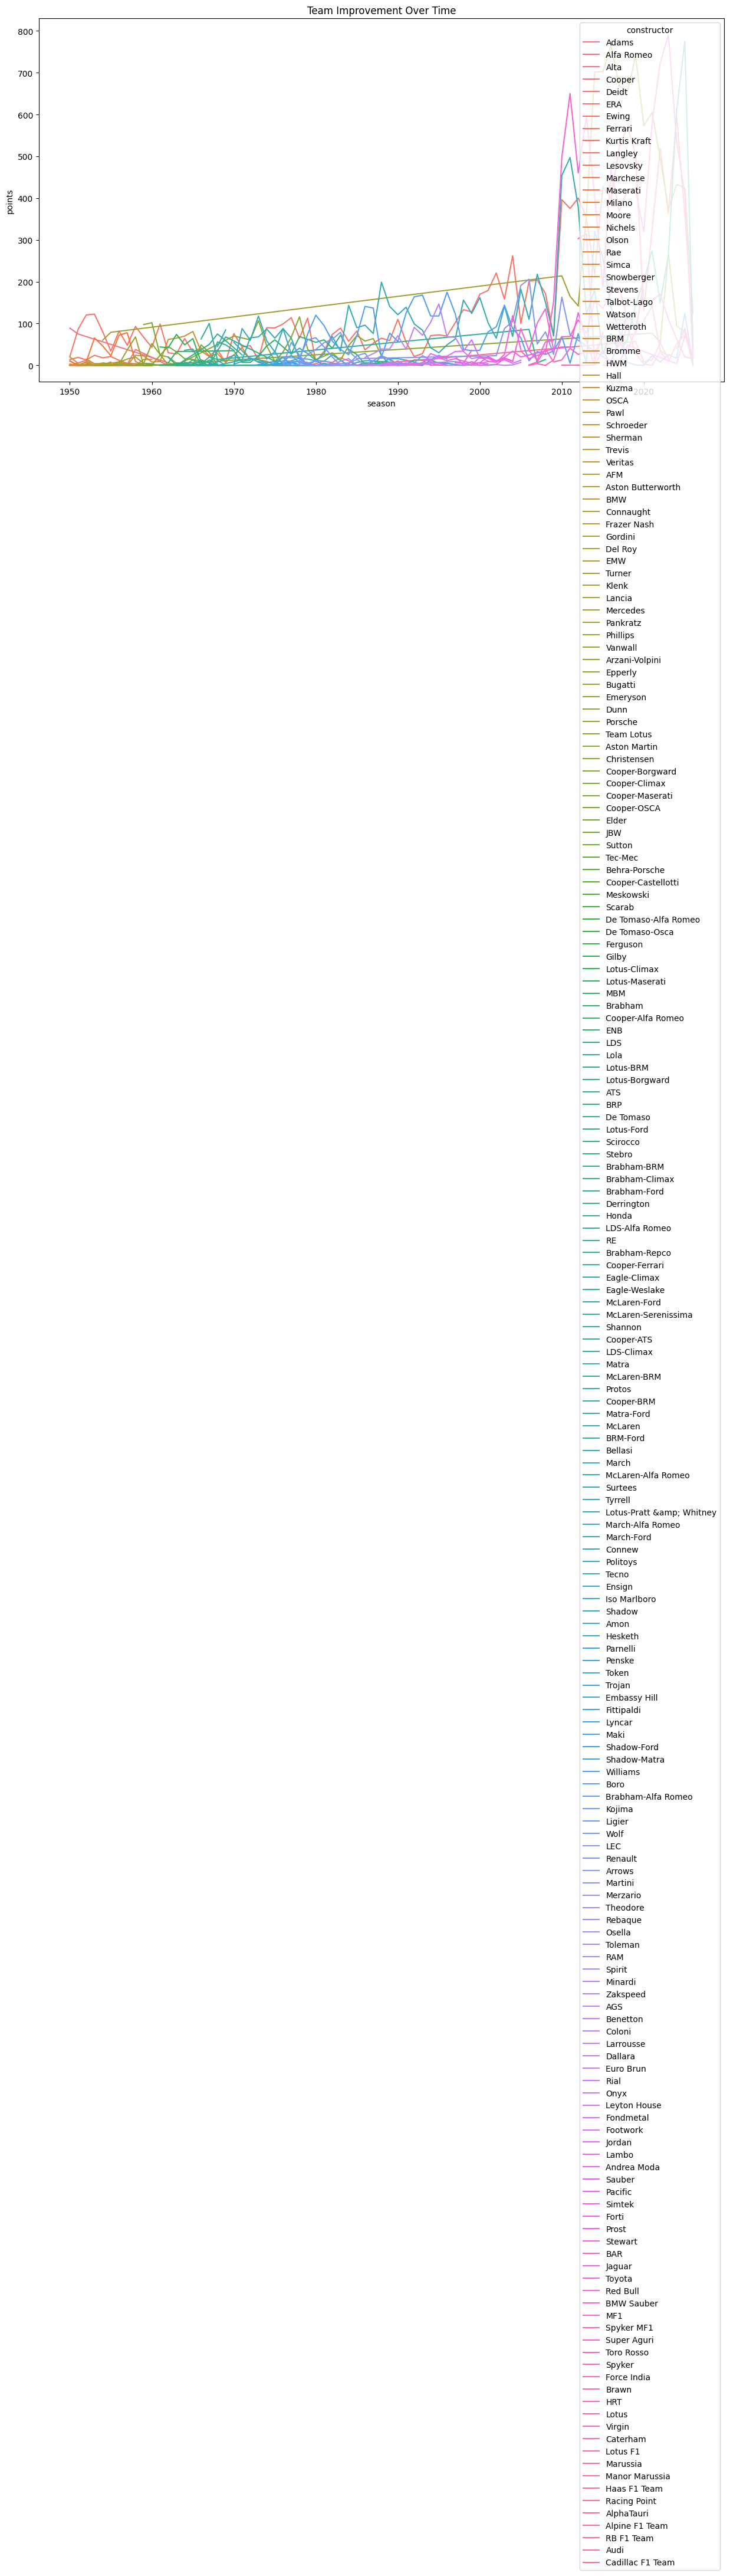

In [65]:
plt.figure(figsize=(15,8))

sns.lineplot(
    x='season',
    y='points',
    hue='constructor',
    data=constructor_trend
)

plt.title("Team Improvement Over Time")

plt.show()

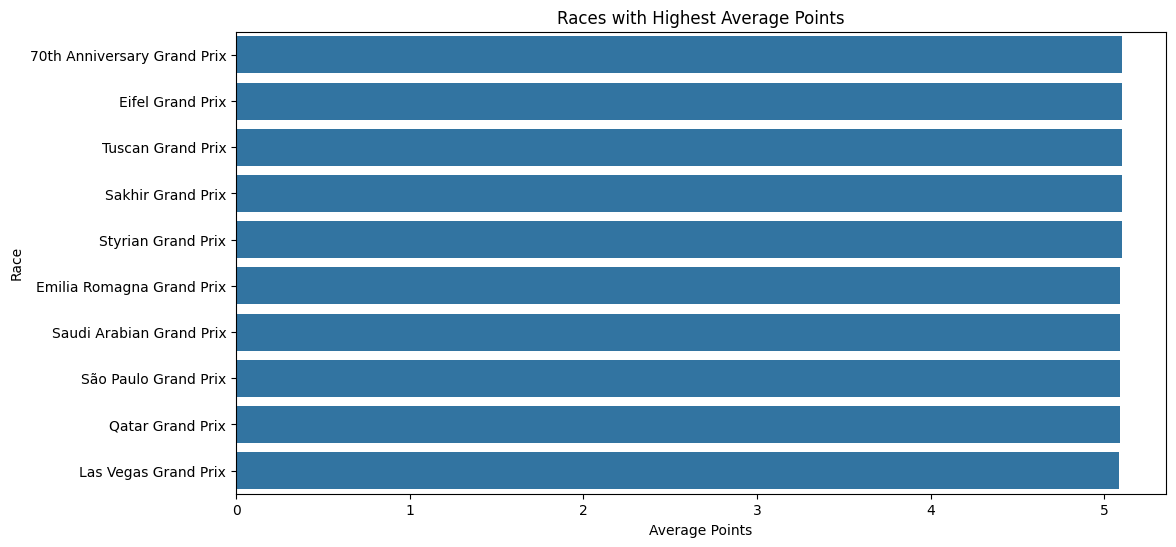

In [69]:
#11
race_points = (
    df.groupby('race_name')['points']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

race_points

plt.figure(figsize=(12,6))

sns.barplot(
    x=race_points.values,
    y=race_points.index
)

plt.title("Races with Highest Average Points")
plt.xlabel("Average Points")
plt.ylabel("Race")

plt.show()

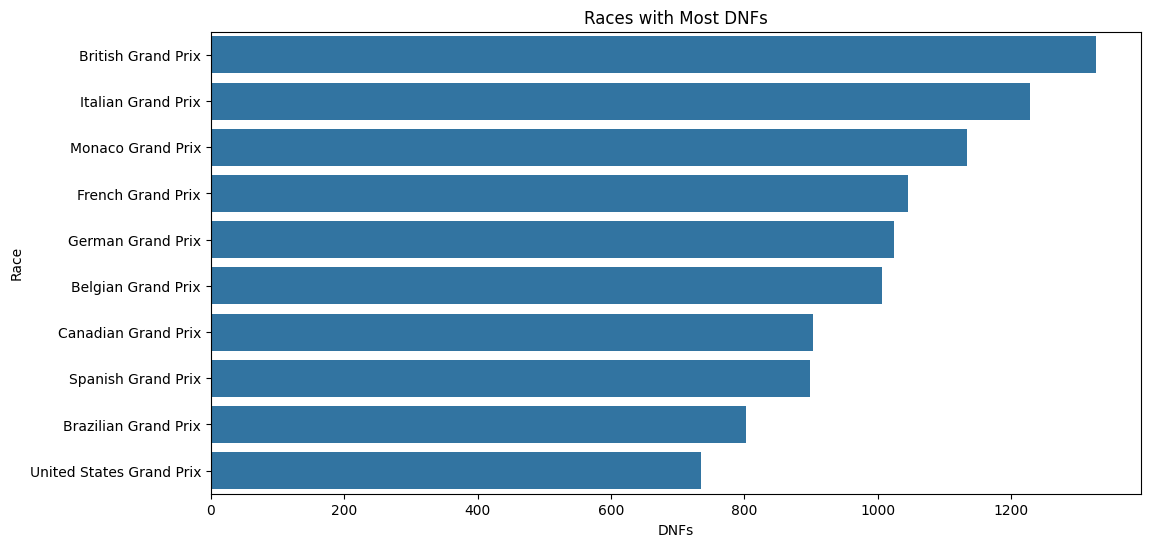

In [70]:
#12
dnf_races = (
    df[df['status'] != 'Finished']
    ['race_name']
    .value_counts()
    .head(10)
)

dnf_races

plt.figure(figsize=(12,6))

sns.barplot(
    x=dnf_races.values,
    y=dnf_races.index
)

plt.title("Races with Most DNFs")
plt.xlabel("DNFs")
plt.ylabel("Race")

plt.show()

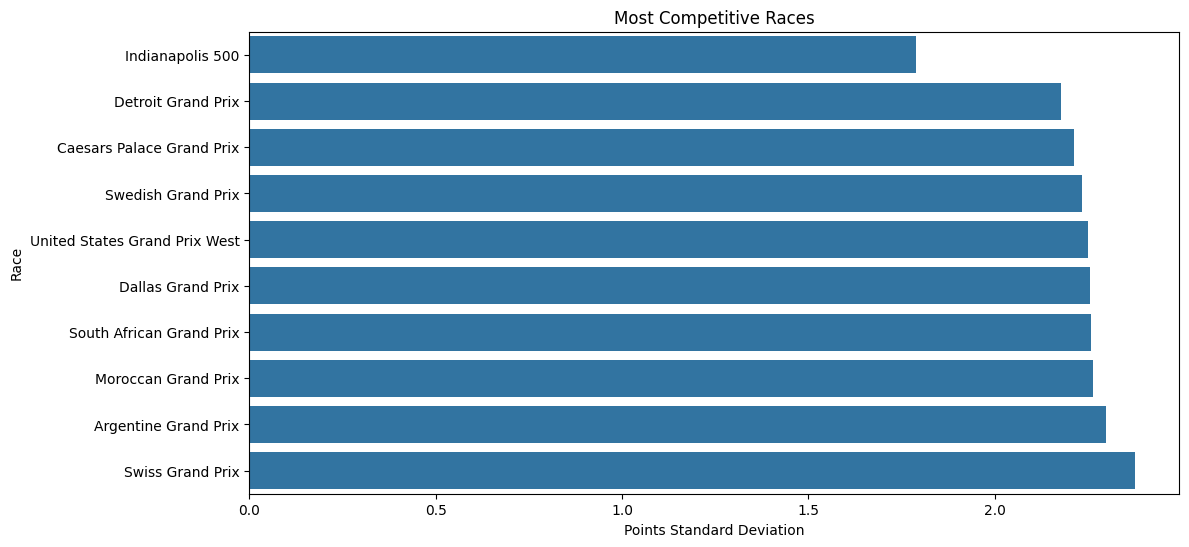

In [72]:
#13
competitive = (
    df.groupby('race_name')['points']
    .std()
    .sort_values()
    .head(10)
)

competitive
plt.figure(figsize=(12,6))

sns.barplot(
    x=competitive.values,
    y=competitive.index
)

plt.title("Most Competitive Races")
plt.xlabel("Points Standard Deviation")
plt.ylabel("Race")

plt.show()

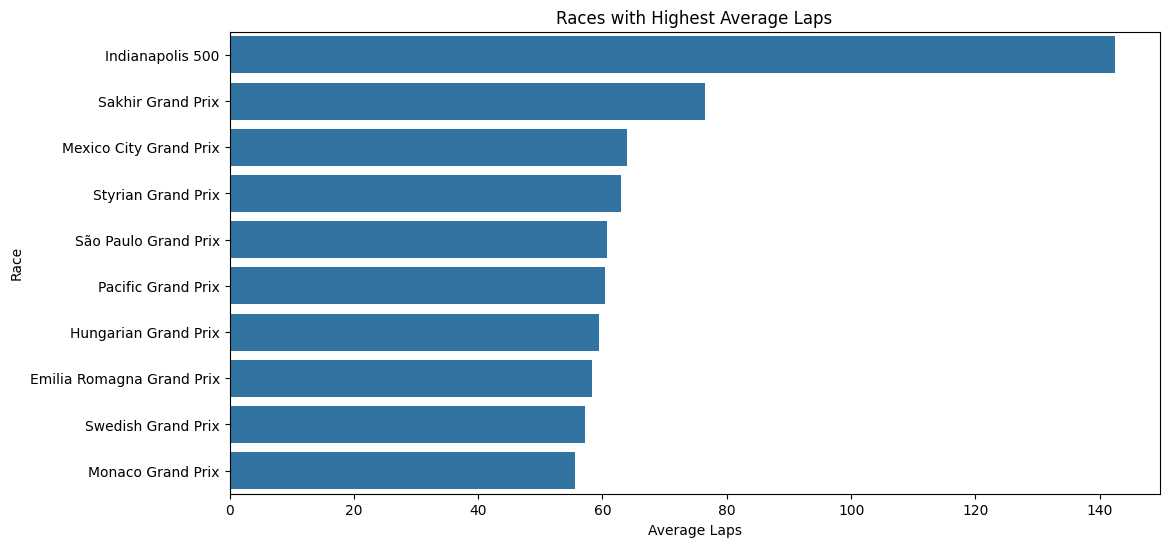

In [77]:
#14
longest_races = (
    df.groupby('race_name')['laps']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=longest_races.values,
    y=longest_races.index
)

plt.title("Races with Highest Average Laps")
plt.xlabel("Average Laps")
plt.ylabel("Race")

plt.show()


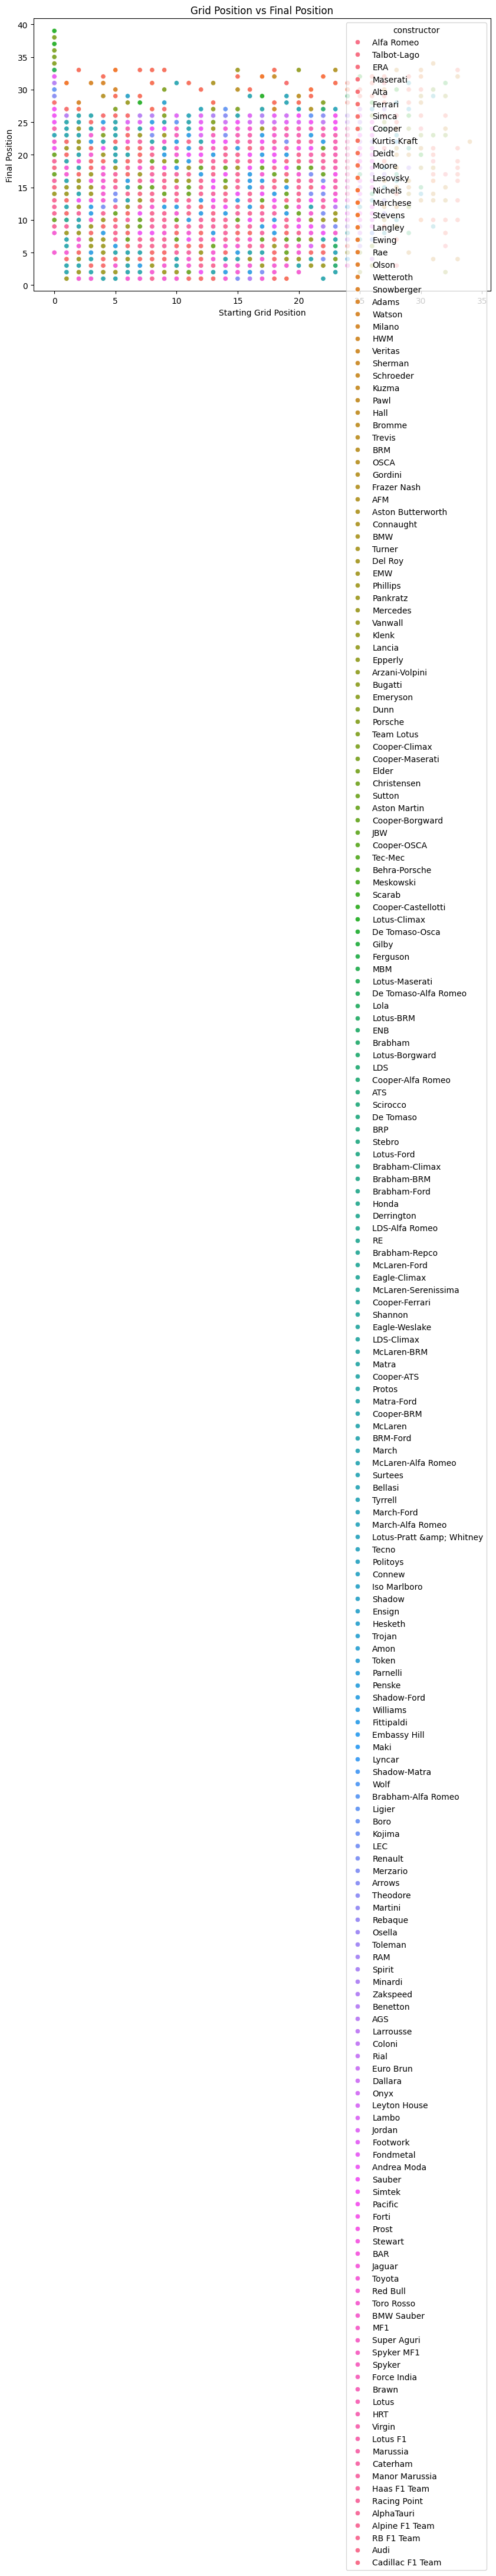

In [78]:
#15
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='grid',
    y='position',
    hue='constructor',
    data=df
)

plt.title("Grid Position vs Final Position")
plt.xlabel("Starting Grid Position")
plt.ylabel("Final Position")

plt.show()

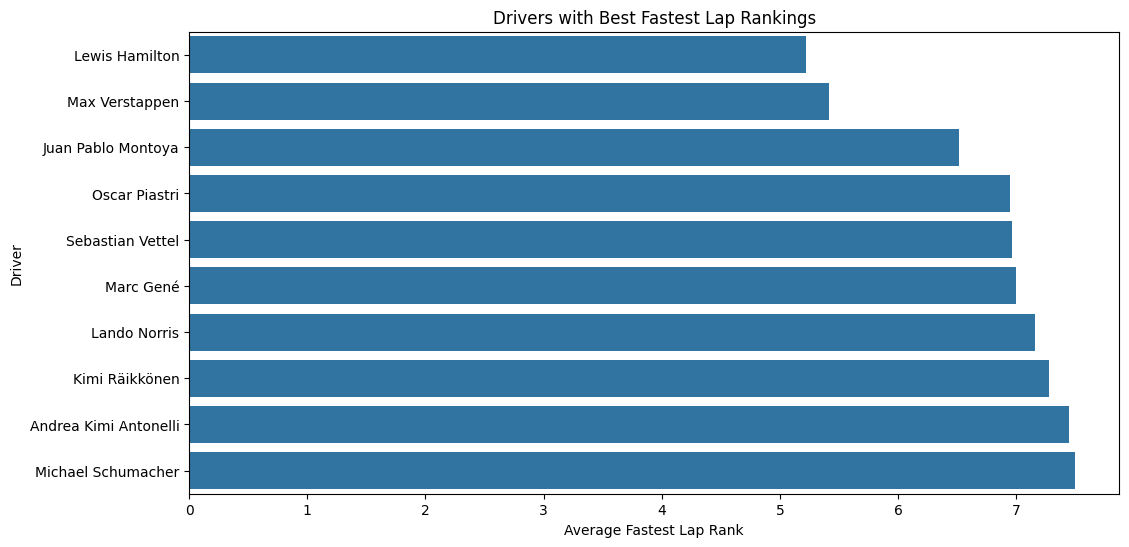

In [79]:
#16

fastest = (
    df.groupby('driver_name')['fastest_lap_rank']
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=fastest.values,
    y=fastest.index
)

plt.title("Drivers with Best Fastest Lap Rankings")
plt.xlabel("Average Fastest Lap Rank")
plt.ylabel("Driver")

plt.show()

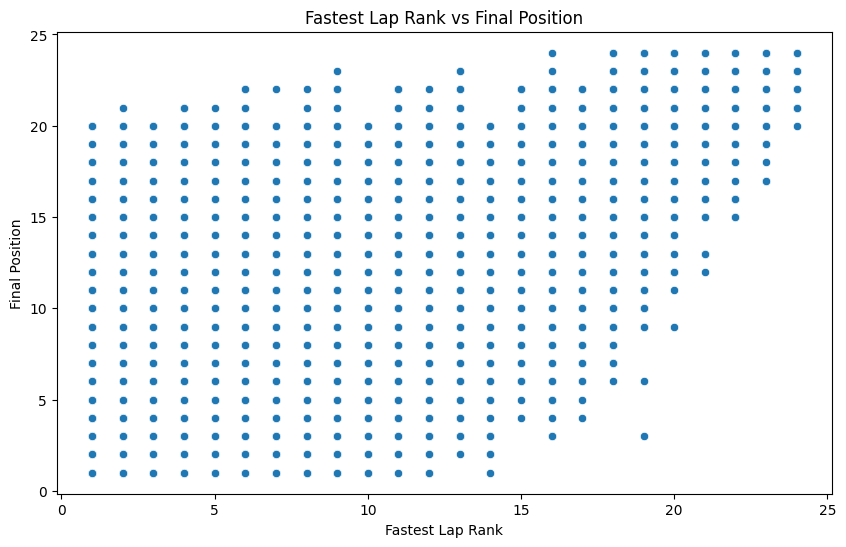

In [80]:
#17
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='fastest_lap_rank',
    y='position',
    data=df
)

plt.title("Fastest Lap Rank vs Final Position")
plt.xlabel("Fastest Lap Rank")
plt.ylabel("Final Position")

plt.show()

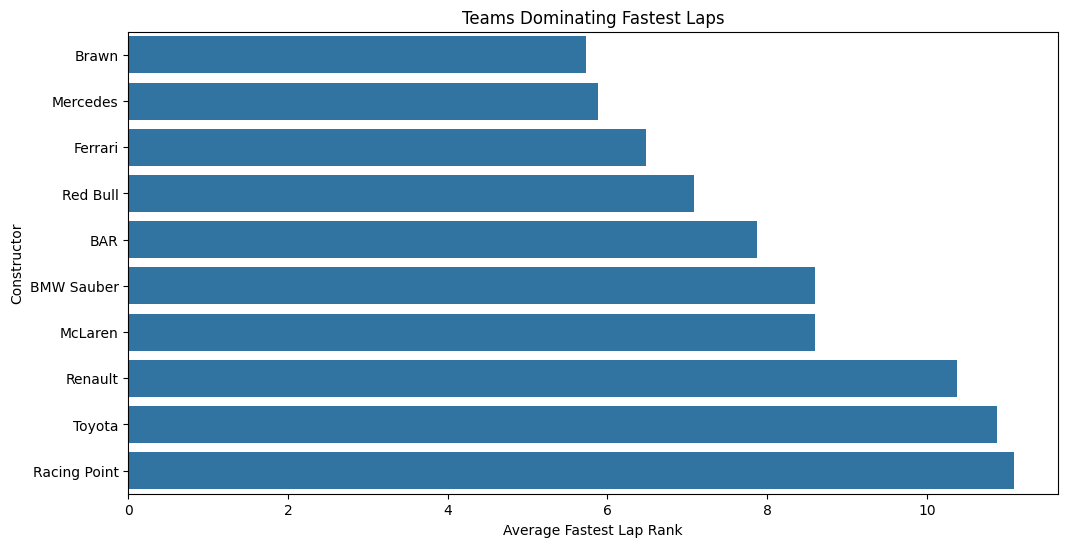

In [82]:
#18
fastest_const = (
    df.groupby('constructor')['fastest_lap_rank']
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=fastest_const.values,
    y=fastest_const.index
)

plt.title("Teams Dominating Fastest Laps")
plt.xlabel("Average Fastest Lap Rank")
plt.ylabel("Constructor")

plt.show()

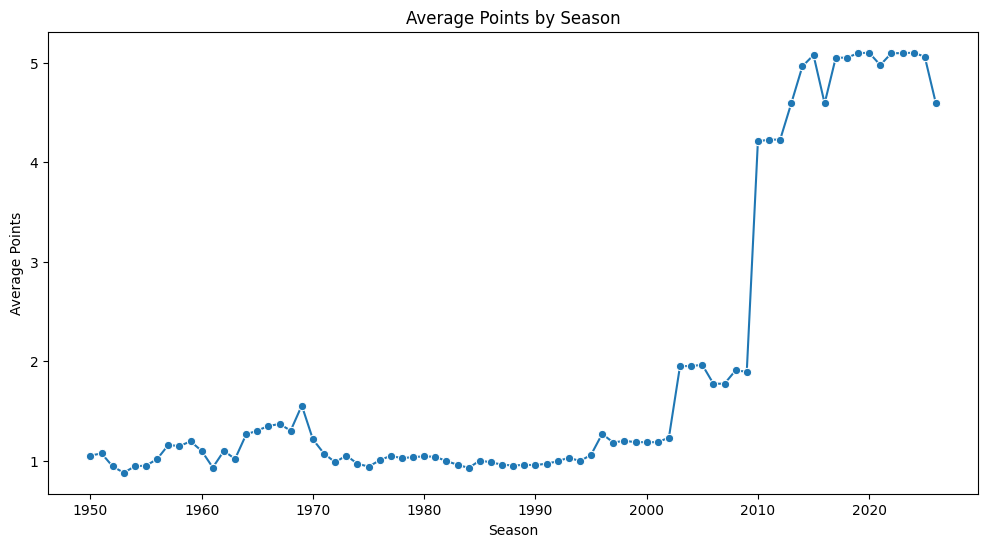

In [83]:
#19
season_avg = (
    df.groupby('season')['points']
    .mean()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=season_avg.index,
    y=season_avg.values,
    marker='o'
)

plt.title("Average Points by Season")
plt.xlabel("Season")
plt.ylabel("Average Points")

plt.show()

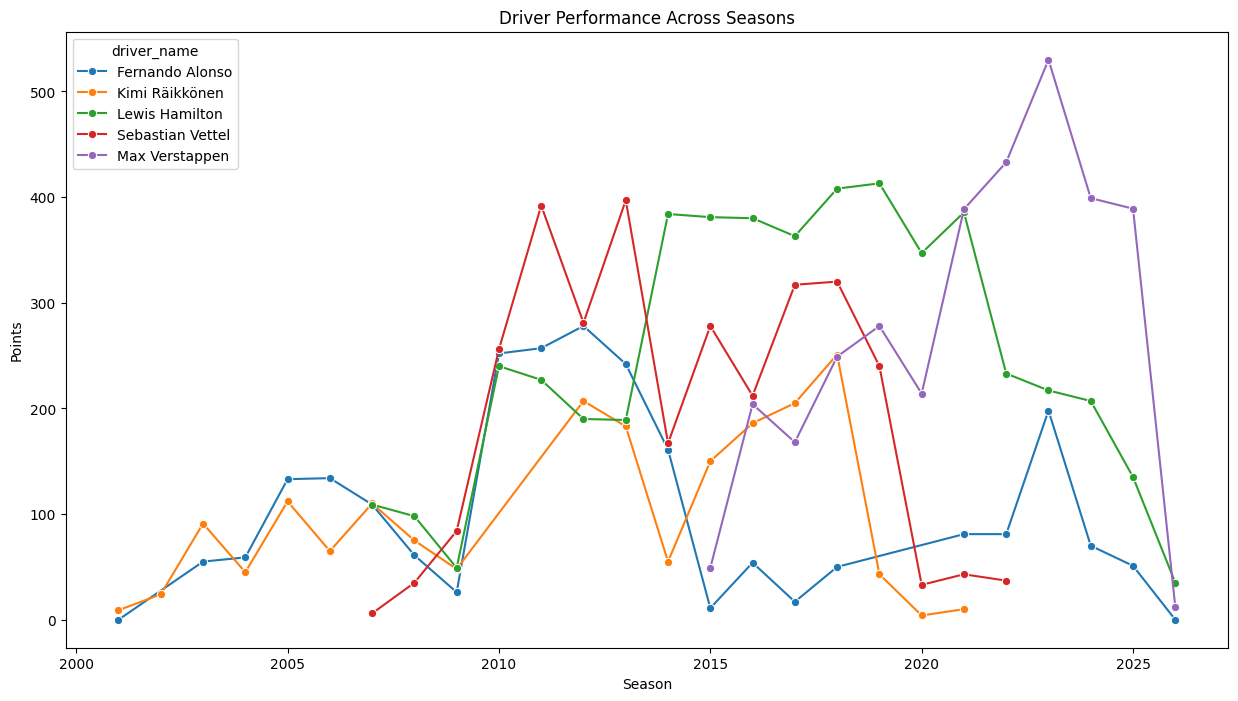

In [84]:
#20

top_drivers = (
    df.groupby('driver_name')['points']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

filtered = df[df['driver_name'].isin(top_drivers)]

driver_trend = (
    filtered.groupby(['season','driver_name'])['points']
    .sum()
    .reset_index()
)

plt.figure(figsize=(15,8))

sns.lineplot(
    x='season',
    y='points',
    hue='driver_name',
    data=driver_trend,
    marker='o'
)

plt.title("Driver Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Points")

plt.show()

In [108]:
driver_trend = (
    df.groupby(['season', 'driver_name'])['points']
    .sum()
    .reset_index()
)

# Bubble chart
fig = px.scatter(
    driver_trend,
    x='season',
    y='points',
    size='points',
    color='driver_name',
    hover_name='driver_name',
    title='Driver Performance Across Seasons',
    size_max=40
)

fig.show()

In [85]:
#map
questions_mapping = pd.DataFrame({
    "Question":[
        "Top drivers by points",
        "Constructors with most wins",
        "Grid vs final position"
    ],

    "Columns Used":[
        "driver_name, points",
        "constructor, position",
        "grid, position"
    ]
})

questions_mapping

,Question,Columns Used
0,Top drivers by points,"driver_name, points"
1,Constructors with most wins,"constructor, position"
2,Grid vs final position,"grid, position"
